<a href="https://colab.research.google.com/github/k74035/Pinn-based-ATC-optimized-methodology/blob/main/PINN_Examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PINN: Simply Supported Beam**

# **1. Simply Supported Beam (Overall Problem Setup)**

![image.png](attachment:image.png)

<br>

## 1.1. Governing Equation

For an Euler–Bernoulli beam, the transverse displacement $y(x)$ satisfies

$$
EI\frac{d^4y}{dx^4}+q(x)=0.
$$

In this example,

$$
E=1,\qquad I=1,\qquad L=1,
$$

and the distributed load is

$$
q(x)=x.
$$

Therefore, the governing equation becomes

$$
\frac{d^4y}{dx^4}+x=0,
\qquad x\in[0,1].
$$

<br>

## 1.2. Problem Setup

- Problem properties

$$
E=1,\qquad I=1,\qquad L=1
$$

- Governing differential equation

$$
y''''(x)+x=0,
\qquad x\in[0,1]
$$

- Simply supported boundary conditions

$$
y(0)=0,\qquad y''(0)=0
$$

$$
y(1)=0,\qquad y''(1)=0
$$

- Quantities of interest

$$
\theta(x)=y'(x),\qquad
M(x)=EIy''(x),\qquad
V(x)=EIy'''(x)
$$

# **2. Lab 1: Forward Problem**

<br>

## 2.1. Solve the Forward Problem

<br>

__Import Library__

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore")

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


<br>

__Define Helper Functions__

Automatic differentiation is used to compute the derivatives of the network output with respect to $x$.

In [ ]:
def derivative(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y).to(device),
        create_graph=True
    )[0]


def requires_grad(x):
    return torch.tensor(
        x,
        dtype=torch.float32,
        requires_grad=True
    ).to(device)

<br>

__Define Exact Solution__

The analytical solution is used only for validation after training.

In [ ]:
def exact_displacement(x):
  return -x**5 / 120 + x**3 / 36 - 7*x / 360

def exact_slope(x):
  return -x**4 / 24 + x**2 / 12 - 7 / 360

def exact_moment(x):
  return -x**3 / 6 + x / 6

def exact_shear(x):
  return -x**2 / 2 + 1 / 6


<br>

__Define Collocation Points__

The PDE residual is evaluated at 25 evenly spaced points over

$$
x\in[0,1].
$$

The two endpoints are also used to enforce the simply supported boundary conditions.

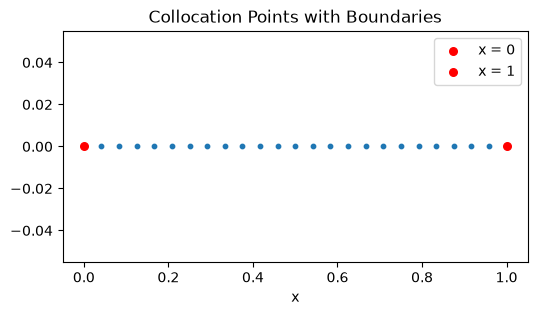

In [ ]:
x_pts = np.linspace(0, 1, 25)

x0 = x_pts[0]                 # Left boundary, x = 0
x1 = x_pts[-1]                # Right boundary, x = 1

plt.figure(figsize=(6, 3))

plt.scatter(x_pts, np.zeros_like(x_pts), s=10)
plt.scatter(x0, 0, label='x = 0', s=30, c='red')
plt.scatter(x1, 0, label='x = 1', s=30, c='red')

plt.xlabel('x')
plt.legend()
plt.title('Collocation Points with Boundaries')

plt.show()

<br>

__Define Network and Hyper-parameters__

The neural network takes the coordinate $x$ as input and predicts the transverse displacement $y(x)$.

In [ ]:
import torch.nn as nn
from torch.nn import Linear, Tanh


class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()

        self.net = nn.Sequential(
            Linear(1, 32),
            Tanh(),

            Linear(32, 32),
            Tanh(),

            Linear(32, 32),
            Tanh(),

            Linear(32, 32),
            Tanh(),

            Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


model = PINN().to(device)

<br>

__Define Functions to Compute Physics Loss__

The PDE residual is

$$
r(x)=y''''(x)+x.
$$

The boundary conditions are

$$
y(0)=y''(0)=0,
\qquad
y(1)=y''(1)=0.
$$

In [ ]:
def PDE(model, x):

    y = model(x)

    y_x = derivative(y, x)
    y_xx = derivative(y_x, x)
    y_xxx = derivative(y_xx, x)
    y_xxxx = derivative(y_xxx, x)

    # Nonuniform distributed transverse load: q(x) = x
    pde = y_xxxx + x

    return pde


In [ ]:
def BC_left(model, x_0):

  y_0 = model(x_0)

  y_x_0 = derivative(y_0, x_0)
  y_xx_0 = derivative(y_x_0, x_0)

  # Simply supported:
  # y(0) = 0
  # y''(0) = 0

  bc1 = y_0
  bc2 = y_xx_0

  return bc1, bc2

def BC_right(model, x_1):

  y_1 = model(x_1)

  y_x_1 = derivative(y_1, x_1)
  y_xx_1 = derivative(y_x_1, x_1)

  # Simply supported:
  # y(1) = 0
  # y''(1) = 0

  bc3 = y_1
  bc4 = y_xx_1

  return bc3, bc4

<br>

__Train__

The total loss combines the governing-equation residual and the boundary-condition errors:

$$
\mathcal{L}
=
\mathcal{L}_{PDE}
+
\mathcal{L}_{BC}.
$$

In [ ]:
def train(model, pde_func, x, x0, x1, epochs=2001):
  optimizer = torch.optim.Adam(
      model.parameters(),
      lr=1e-3
  )

  loss_fn = nn.MSELoss()

  for epoch in range(epochs):

      # Physics residual
      pde_term = pde_func(model, x)

      # Boundary conditions
      bc1, bc2 = BC_left(model, x0)
      bc3, bc4 = BC_right(model, x1)

      # PDE loss
      loss_pde = loss_fn(
          pde_term,
          torch.zeros_like(pde_term).to(device)
      )

      # Boundary losses
      loss_bc1 = loss_fn(bc1, torch.zeros_like(bc1))
      loss_bc2 = loss_fn(bc2, torch.zeros_like(bc2))
      loss_bc3 = loss_fn(bc3, torch.zeros_like(bc3))
      loss_bc4 = loss_fn(bc4, torch.zeros_like(bc4))

      loss_bc = loss_bc1 + loss_bc2 + loss_bc3 + loss_bc4

      # Total loss
      loss = loss_pde + loss_bc

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      if epoch % 500 == 0:

          print(
              'Epoch: {} Loss: {:.6f} PDELoss: {:.6f} BCLoss: {:.6f}'.format(
                  epoch,
                  loss.item(),
                  loss_pde.item(),
                  loss_bc.item()
              )
          )
  return model


In [ ]:
x = requires_grad(x_pts.reshape(-1, 1))

x0 = requires_grad(np.array([[x0]]))
x1 = requires_grad(np.array([[x1]]))

In [ ]:
print("Training PINN")

model = train(
    model,
    PDE,
    x,
    x0,
    x1
)


Training PINN
Epoch: 0 Loss: 0.393663 PDELoss: 0.353105 BCLoss: 0.040558
Epoch: 500 Loss: 0.000020 PDELoss: 0.000020 BCLoss: 0.000000
Epoch: 1000 Loss: 0.000011 PDELoss: 0.000011 BCLoss: 0.000000
Epoch: 1500 Loss: 0.000004 PDELoss: 0.000004 BCLoss: 0.000000
Epoch: 2000 Loss: 0.000002 PDELoss: 0.000002 BCLoss: 0.000000


<br>

__Result__

The trained PINN is evaluated on 100 points and compared with the analytical solution for displacement, slope, bending moment, and shear force.

<br>

__Compute Predicted Quantities__

In [ ]:
def predict_quantities(model, x_test):

    x_tensor = torch.tensor(
        x_test.reshape(-1, 1),
        dtype=torch.float32,
        requires_grad=True
    ).to(device)

    model.eval()

    y = model(x_tensor)

    y_x = derivative(y, x_tensor)
    y_xx = derivative(y_x, x_tensor)
    y_xxx = derivative(y_xx, x_tensor)

    displacement = y.detach().cpu().numpy().flatten()
    slope = y_x.detach().cpu().numpy().flatten()

    E = 1.0
    I = 1.0

    moment = (
        E * I * y_xx
    ).detach().cpu().numpy().flatten()

    shear = (
        E * I * y_xxx
    ).detach().cpu().numpy().flatten()

    return displacement, slope, moment, shear

<br>

__Define Test Points__

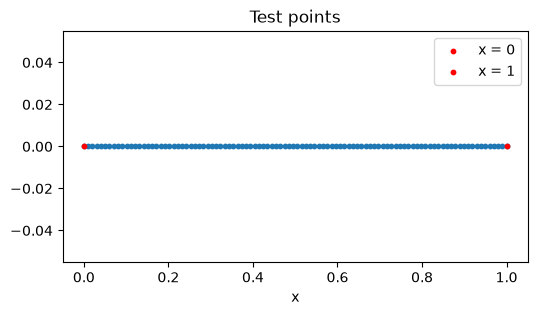

In [ ]:
x_test = np.linspace(0, 1, 100)

x0 = x_test[0]                # Left boundary of y = 0
x1 = x_test[-1]               # Right boundary of y = 1

plt.figure(figsize = (6, 3))
plt.scatter(x_test, np.zeros_like(x_test), s = 10)
plt.scatter(x0, 0, label = 'x = 0', s = 10, c = 'red')
plt.scatter(x1, 0, label = 'x = 1', s = 10, c = 'red')
plt.xlabel('x')
plt.legend()
plt.title('Test points')
plt.show()

In [ ]:
y, slope, moment, shear = predict_quantities(model, x_test)


<br>

__Displacement__

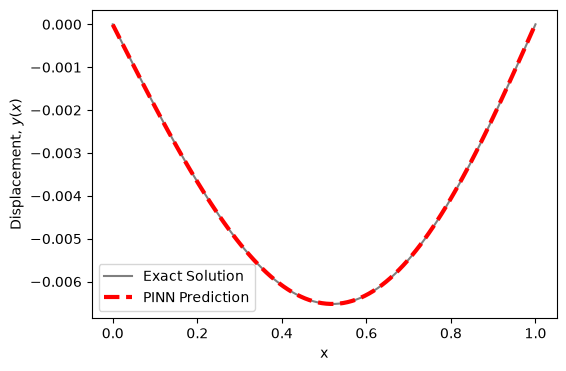

In [ ]:
# plot displacement (prediction vs exact solution)
plt.figure(figsize=(6, 4))

plt.plot(
    x_test,
    exact_displacement(x_test),
    c='k',
    label='Exact Solution',
    alpha=0.5
)

plt.plot(
    x_test,
    y,
    c='r',
    label='PINN Prediction',
    linestyle='--',
    linewidth=3
)

plt.xlabel('x')
plt.ylabel(r'Displacement, $y(x)$')
plt.legend()

plt.show()

<br>

__Slope__

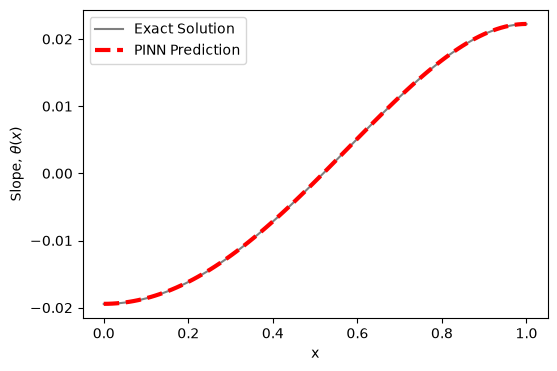

In [ ]:
plt.figure(figsize=(6, 4))

plt.plot(
    x_test,
    exact_slope(x_test),
    c='k',
    label='Exact Solution',
    alpha=0.5
)

plt.plot(
    x_test,
    slope,
    c='r',
    label='PINN Prediction',
    linestyle='--',
    linewidth=3
)

plt.xlabel('x')
plt.ylabel(r'Slope, $\theta(x)$')
plt.legend()

plt.show()

<br>

__Bending Moment__

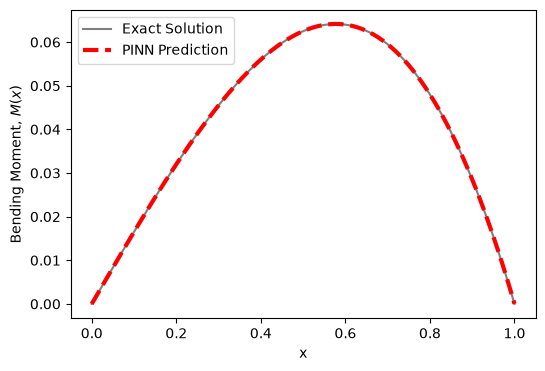

In [ ]:
plt.figure(figsize=(6, 4))

plt.plot(
    x_test,
    exact_moment(x_test),
    c='k',
    label='Exact Solution',
    alpha=0.5
)

plt.plot(
    x_test,
    moment,
    c='r',
    label='PINN Prediction',
    linestyle='--',
    linewidth=3
)

plt.xlabel('x')
plt.ylabel(r'Bending Moment, $M(x)$')
plt.legend()

plt.show()

<br>

__Shear Force__

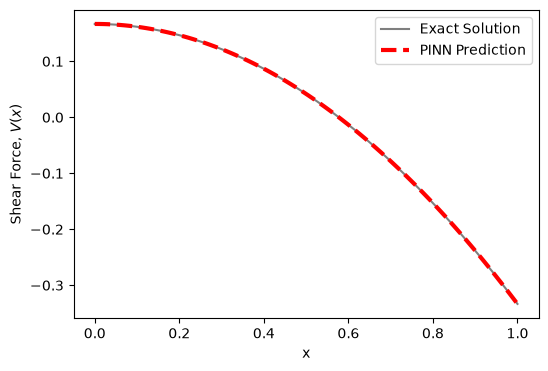

In [ ]:
plt.figure(figsize=(6, 4))

plt.plot(
    x_test,
    exact_shear(x_test),
    c='k',
    label='Exact Solution',
    alpha=0.5
)

plt.plot(
    x_test,
    shear,
    c='r',
    label='PINN Prediction',
    linestyle='--',
    linewidth=3
)

plt.xlabel('x')
plt.ylabel(r'Shear Force, $V(x)$')
plt.legend()

plt.show()

<br><br>

# 3. Summary

The PINN solves the forward Euler–Bernoulli beam problem using only the governing equation and boundary conditions.

The network predicts the displacement field $y(x)$, and automatic differentiation provides the slope, bending moment, and shear force:

$$
\theta=y',\qquad
M=EIy'',\qquad
V=EIy'''.
$$

The analytical solution is used only to evaluate the trained PINN.

# **PINN: Unsteady Drainage of a Tank**

# **1. Unsteady drainage of a tank (Overall problem setup)**

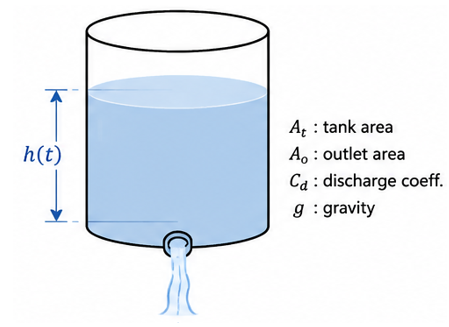

- $h(t)$ : 시간 $t$에서의 수위
- $A_t$ : 탱크 단면적
- $A_o$ : 배출구(orifice) 면적
- $C_d$ : 배출계수
- $g$ : 중력가속도

An open tank is filled with water to an initial level. A small orifice at the bottom lets
the water out. The higher the water level, the faster the water leaves; as water leaves,
the level drops; as the level drops, the outflow slows down again.

That feedback is what makes this a differential equation. Without it, it would be a
division.

<br>

## 1.1. Governing Equation

Mass conservation for the water in the tank states that the rate of change of the stored
volume equals minus the outflow rate. **Torricelli's law** gives the outflow velocity: the
water leaving the orifice moves as fast as if it had fallen freely from the free surface,

$$gh = \frac{1}{2}v^2 \quad \Longrightarrow \quad v = \sqrt{2gh}$$

This form assumes the free surface itself is essentially at rest, which holds when the tank
is much wider than the orifice, $A_o \ll A_t$.

In practice the jet contracts (vena contracta) and friction takes a further toll, so less
comes out. That loss is lumped into a single discharge coefficient $C_d$ (about $0.6$ for a
sharp-edged orifice). Writing $A_t$ for the tank cross-section and $A_o$ for the orifice
area,

$$A_t \frac{dh}{dt} = -C_d A_o \sqrt{2gh}$$

We collect the four constants into one,

$$C = \frac{C_d A_o \sqrt{2g}}{A_t}$$

so that the problem carries a single number. The equation is a **first-order, nonlinear
ODE**, and it comes with an **initial condition**, not a boundary condition.

<br>

## 1.2. Problem Setup

- Problem properties (nondimensionalized)

$$C = 1$$

- Ordinary differential equation

$$\frac{dh}{dt} = -C\sqrt{h}, \qquad \text{where} \quad t \in [0, 2]$$

- One initial condition

$$h(0) = 1$$

- The exact solution

$$h(t) = \left(1 - \frac{Ct}{2}\right)^2 \qquad \text{for} \quad t \le \frac{2}{C},
\qquad h(t) = 0 \quad \text{after that}$$

<br>

## 1.3. Three Labs

| Lab | Setting | Question |
|---|---|---|
| 1 | $C$ is known | Can a PINN reproduce the exact solution? |
| 2 | $C$ is unknown, no data | Can the physics alone pin down $C$? |
| 3 | $C$ is unknown, a few measurements | Can physics and data together recover $C$? |

Lab 2 and Lab 3 are **inverse problems**: we solve for the solution and for an unknown
property of the system at the same time.

# **2. Lab 1: Forward Problem**

<br>

## 2.1. Solve the Forward Problem

<br>

__Import Library__

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.nn import Linear, Tanh
import matplotlib.pyplot as plt

from warnings import filterwarnings
filterwarnings('ignore')

<br>

__Set the Random Seed__

In [ ]:
import random

seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


<br>

__Define Helper Functions__

In [ ]:
def derivative(y, t):
    return torch.autograd.grad(y, t, grad_outputs = torch.ones_like(y).to(device),
                               create_graph = True)[0]

def requires_grad(x):
    return torch.tensor(x, dtype = torch.float32, requires_grad = True).to(device)

<br>

__Define Exact Solution__

In [ ]:
def exact_solution(t):
    return (1 - t/2)**2

<br>

__Define Collocation Points__

The residual is evaluated at 100 points drawn uniformly from $[0, 2]$, redrawn at every
iteration. Collocation points are not a mesh: they carry no connectivity, no ordering, and
nothing stops us from throwing them away and sampling again.

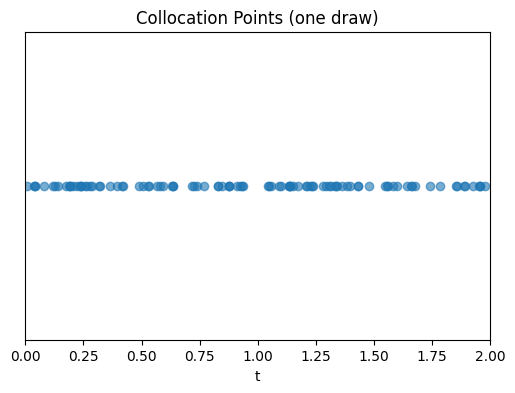

In [ ]:
t_train = np.random.rand(100, 1)*2

plt.figure(figsize = (6, 4))
plt.plot(t_train, np.zeros_like(t_train), 'o', alpha = 0.6)
plt.xlim([0, 2])
plt.yticks([])
plt.xlabel('t')
plt.title('Collocation Points (one draw)')
plt.show()

<br>

__Define Network and Hyper-parameters__

In [ ]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            Linear(1, 32),
            Tanh(),
            Linear(32, 32),
            Tanh(),
            Linear(32, 32),
            Tanh(),
            Linear(32, 32),
            Tanh(),
            Linear(32, 1)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        return self.net(t)

In [ ]:
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)
loss_fn = nn.MSELoss()

<br>

__Define Functions to Compute Physics Loss__

The network output can go negative early in training, and $\sqrt{h}$ would then return
`NaN`. Clamping inside the square root keeps the residual finite. The clamp is inactive
wherever $h \ge 0$, so it does not alter the equation on the physical range of the solution.

In [ ]:
def ODE(model, t, C):
    h = model(t)
    dh_t = derivative(h, t)
    return dh_t + C*torch.sqrt(torch.clamp(h, min = 0.0) + 1e-8)

<br>

__Train__

$$\mathcal{L} = \mathcal{L}_{ODE} + \mathcal{L}_{IC}$$

In [ ]:
C = 1.0
t_0 = requires_grad(np.zeros((1, 1)))

for epoch in range(5001):
    t = requires_grad(np.random.rand(100, 1)*2)

    ODE_term = ODE(model, t, C)
    loss_ODE = loss_fn(ODE_term, torch.zeros_like(ODE_term))

    h_0 = model(t_0)
    loss_IC = loss_fn(h_0, torch.ones_like(h_0))

    loss = loss_ODE + loss_IC

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f'Epoch: {epoch} Loss: {loss.item():.6f} '
              f'ODELoss: {loss_ODE.item():.6f} ICLoss: {loss_IC.item():.6f}')

Epoch: 0 Loss: 1.258846 ODELoss: 0.258846 ICLoss: 1.000000
Epoch: 500 Loss: 0.001623 ODELoss: 0.001623 ICLoss: 0.000000
Epoch: 1000 Loss: 0.003543 ODELoss: 0.003520 ICLoss: 0.000023
Epoch: 1500 Loss: 0.001173 ODELoss: 0.001172 ICLoss: 0.000001
Epoch: 2000 Loss: 0.000895 ODELoss: 0.000895 ICLoss: 0.000000
Epoch: 2500 Loss: 0.000495 ODELoss: 0.000494 ICLoss: 0.000000
Epoch: 3000 Loss: 0.000878 ODELoss: 0.000871 ICLoss: 0.000007
Epoch: 3500 Loss: 0.000415 ODELoss: 0.000414 ICLoss: 0.000000
Epoch: 4000 Loss: 0.000528 ODELoss: 0.000524 ICLoss: 0.000003
Epoch: 4500 Loss: 0.000489 ODELoss: 0.000489 ICLoss: 0.000000
Epoch: 5000 Loss: 0.000881 ODELoss: 0.000868 ICLoss: 0.000013


<br>

__Result__

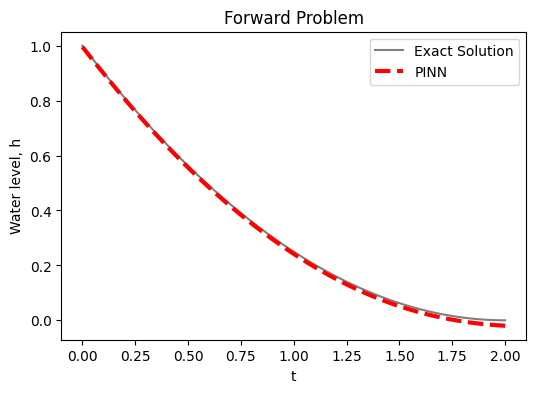

In [ ]:
t_test = np.linspace(0, 2, 100).reshape(-1, 1)
h_pred = model(requires_grad(t_test)).detach().cpu().numpy()

plt.figure(figsize = (6, 4))
plt.plot(t_test, exact_solution(t_test), c = 'k', label = 'Exact Solution', alpha = 0.5)
plt.plot(t_test, h_pred, c = 'r', label = 'PINN', linestyle = '--', linewidth = 3)
plt.legend()
plt.xlabel('t')
plt.ylabel('Water level, h')
plt.title('Forward Problem')
plt.show()

In [ ]:
h_exact = exact_solution(t_test)
rel_l2 = np.linalg.norm(h_pred - h_exact)/np.linalg.norm(h_exact)

print(f'Relative L2 error: {rel_l2:.4f}')

Relative L2 error: 0.0217


# **3. Lab 2: Inverse Problem without Observed Data**

<br>

## 3.1. Problem Setup

Now the drainage constant is not given.

- Unknown property

$$\color{red}{C = \;?}$$

- Ordinary differential equation

$$\frac{dh}{dt} = -\color{red}{C}\sqrt{h}, \qquad h(0) = 1$$

$C$ becomes a trainable parameter, optimized jointly with the network weights. It is
initialized at $0.5$, away from the true value, so that any agreement at the end is earned
rather than assumed.

Nothing else changes — the loss still has only the two physics terms.

<br>

## 3.2. Solve the Inverse Problem

<br>

__Define Network and Unknown Parameter__

In [ ]:
model = PINN().to(device)
C = (0.5*torch.ones(1)).to(device).requires_grad_(True)

optimizer = torch.optim.Adam([{'params': model.parameters(), 'lr': 1e-3},
                              {'params': C, 'lr': 1e-3}])
loss_fn = nn.MSELoss()

<br>

__Train__

In [ ]:
C_list = []

for epoch in range(5001):
    t = requires_grad(np.random.rand(100, 1)*2)

    ODE_term = ODE(model, t, C)
    loss_ODE = loss_fn(ODE_term, torch.zeros_like(ODE_term))

    h_0 = model(t_0)
    loss_IC = loss_fn(h_0, torch.ones_like(h_0))

    loss = loss_ODE + loss_IC

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    C_list.append(C.item())

    if epoch % 500 == 0:
        print(f'Epoch: {epoch} Loss: {loss.item():.6f} C: {C.item():.4f}')

Epoch: 0 Loss: 1.001216 C: 0.5010
Epoch: 500 Loss: 0.000248 C: 0.4401
Epoch: 1000 Loss: 0.000041 C: 0.4197
Epoch: 1500 Loss: 0.000058 C: 0.4033
Epoch: 2000 Loss: 0.000026 C: 0.3883
Epoch: 2500 Loss: 0.000018 C: 0.3753
Epoch: 3000 Loss: 0.000013 C: 0.3639
Epoch: 3500 Loss: 0.000009 C: 0.3551
Epoch: 4000 Loss: 0.000004 C: 0.3481
Epoch: 4500 Loss: 0.000004 C: 0.3421
Epoch: 5000 Loss: 0.000002 C: 0.3375


<br>

__Result__

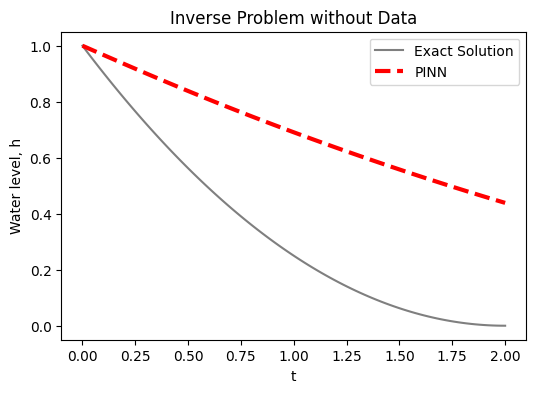

In [ ]:
h_pred = model(requires_grad(t_test)).detach().cpu().numpy()

plt.figure(figsize = (6, 4))
plt.plot(t_test, exact_solution(t_test), c = 'k', label = 'Exact Solution', alpha = 0.5)
plt.plot(t_test, h_pred, c = 'r', label = 'PINN', linestyle = '--', linewidth = 3)
plt.legend()
plt.xlabel('t')
plt.ylabel('Water level, h')
plt.title('Inverse Problem without Data')
plt.show()

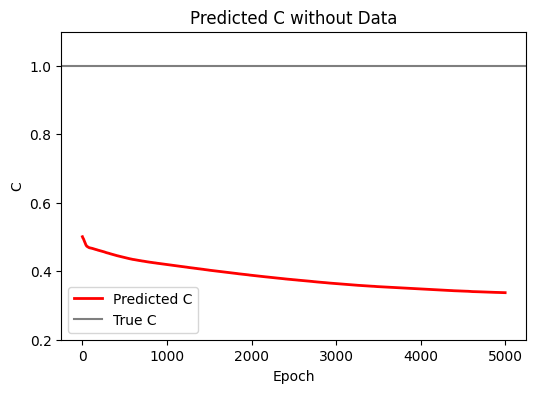

In [ ]:
plt.figure(figsize = (6, 4))
plt.plot(C_list, c = 'r', linewidth = 2, label = 'Predicted C')
plt.axhline(1.0, c = 'k', alpha = 0.5, label = 'True C')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('C')
plt.ylim([0.2, 1.1])
plt.title('Predicted C without Data')
plt.show()

In [ ]:
print(f'True C: 1.0000, Predicted C: {C.item():.4f}')

True C: 1.0000, Predicted C: 0.3375


<br><br>

# 4. Lab 3: Inverse Problem with Observed Data

<br>

## 4.1. Define Observed Data

Suppose the water level was read nine times during the experiment. The readings are
generated from the exact solution with $C = 1$ and corrupted with a small amount of noise;
$C$ is of course assumed to be unknown throughout this lab.

The readings are taken between $t = 0.2$ and $t = 1.6$, away from both ends of the domain.
How much a reading tells us about $C$ is the sensitivity of the level to $C$,

$$\frac{\partial h}{\partial C} = -t\left(1 - \frac{Ct}{2}\right)$$

Evaluated at the true value $C = 1$, this vanishes at $t = 0$, where the level is pinned by
the initial condition, and again at $t = 2$, where the tank has just emptied. It is largest
in magnitude at $t = 1$. **A sensor placed at either end would carry no information about
$C$**, which is why the readings sit in the middle.

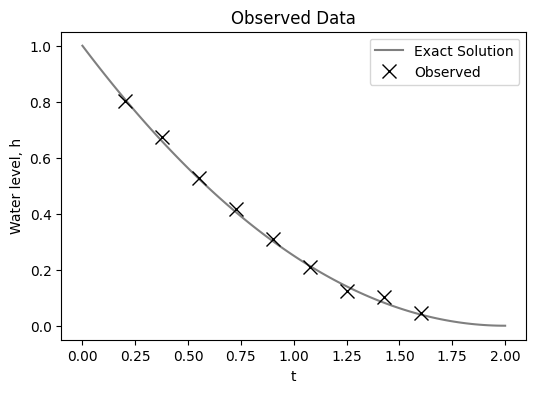

In [ ]:
t_obs = np.linspace(0.2, 1.6, 9).reshape(-1, 1)
h_obs = exact_solution(t_obs) + 0.01*np.random.randn(9, 1)

plt.figure(figsize = (6, 4))
plt.plot(t_test, exact_solution(t_test), c = 'k', label = 'Exact Solution', alpha = 0.5)
plt.plot(t_obs, h_obs, 'kx', markersize = 10, label = 'Observed')
plt.legend()
plt.xlabel('t')
plt.ylabel('Water level, h')
plt.title('Observed Data')
plt.show()

<br>

## 4.2. Solve the Inverse Problem

<br>

__Define Data-Driven Loss Term__

$$\mathcal{L} = \mathcal{L}_{ODE} + \mathcal{L}_{IC} + \mathcal{L}_{DATA}$$

In [ ]:
model = PINN().to(device)
C = (0.5*torch.ones(1)).to(device).requires_grad_(True)

optimizer = torch.optim.Adam([{'params': model.parameters(), 'lr': 1e-3},
                              {'params': C, 'lr': 1e-3}])
loss_fn = nn.MSELoss()

In [ ]:
t_data = requires_grad(t_obs)
h_data = torch.tensor(h_obs, dtype = torch.float32).to(device)

<br>

__Train__

In [ ]:
C_list = []

for epoch in range(5001):
    t = requires_grad(np.random.rand(100, 1)*2)

    ODE_term = ODE(model, t, C)
    loss_ODE = loss_fn(ODE_term, torch.zeros_like(ODE_term))

    h_0 = model(t_0)
    loss_IC = loss_fn(h_0, torch.ones_like(h_0))

    h_pred_data = model(t_data)
    loss_DATA = loss_fn(h_pred_data, h_data)

    loss = loss_ODE + loss_IC + loss_DATA

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    C_list.append(C.item())

    if epoch % 500 == 0:
        print(f'Epoch: {epoch} Loss: {loss.item():.6f} '
              f'ODELoss: {loss_ODE.item():.6f} '
              f'DATALoss: {loss_DATA.item():.6f} C: {C.item():.4f}')

Epoch: 0 Loss: 1.280887 ODELoss: 0.011743 DATALoss: 0.269143 C: 0.5010
Epoch: 500 Loss: 0.003870 ODELoss: 0.001270 DATALoss: 0.002141 C: 0.8173
Epoch: 1000 Loss: 0.001339 ODELoss: 0.000697 DATALoss: 0.000567 C: 0.9202
Epoch: 1500 Loss: 0.000912 ODELoss: 0.000622 DATALoss: 0.000278 C: 0.9559
Epoch: 2000 Loss: 0.003018 ODELoss: 0.002803 DATALoss: 0.000119 C: 0.9530
Epoch: 2500 Loss: 0.046732 ODELoss: 0.033424 DATALoss: 0.009407 C: 0.9360
Epoch: 3000 Loss: 0.001013 ODELoss: 0.000761 DATALoss: 0.000252 C: 0.9701
Epoch: 3500 Loss: 0.002032 ODELoss: 0.001567 DATALoss: 0.000463 C: 0.9707
Epoch: 4000 Loss: 0.002152 ODELoss: 0.001602 DATALoss: 0.000535 C: 0.9673
Epoch: 4500 Loss: 0.000624 ODELoss: 0.000485 DATALoss: 0.000128 C: 0.9719
Epoch: 5000 Loss: 0.000514 ODELoss: 0.000370 DATALoss: 0.000136 C: 0.9704


<br>

__Result__

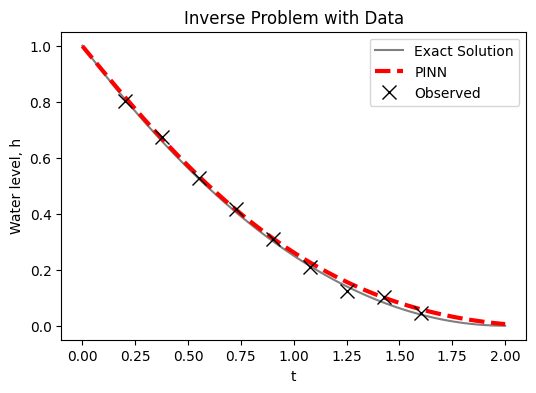

In [ ]:
h_pred = model(requires_grad(t_test)).detach().cpu().numpy()

plt.figure(figsize = (6, 4))
plt.plot(t_test, exact_solution(t_test), c = 'k', label = 'Exact Solution', alpha = 0.5)
plt.plot(t_test, h_pred, c = 'r', label = 'PINN', linestyle = '--', linewidth = 3)
plt.plot(t_obs, h_obs, 'kx', markersize = 10, label = 'Observed')
plt.legend()
plt.xlabel('t')
plt.ylabel('Water level, h')
plt.title('Inverse Problem with Data')
plt.show()

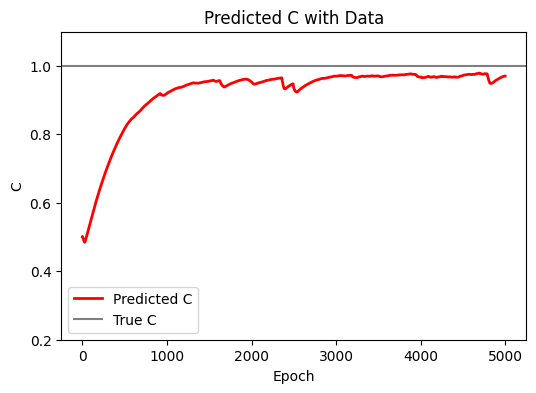

In [ ]:
plt.figure(figsize = (6, 4))
plt.plot(C_list, c = 'r', linewidth = 2, label = 'Predicted C')
plt.axhline(1.0, c = 'k', alpha = 0.5, label = 'True C')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('C')
plt.ylim([0.2, 1.1])
plt.title('Predicted C with Data')
plt.show()

In [ ]:
print(f'True C: 1.0000, Predicted C: {C.item():.4f}')

True C: 1.0000, Predicted C: 0.9704


<br>

Nine noisy readings are enough to close the system. The same network, the same equation and
one extra loss term now recover the drainage constant.

Note where the curve is least accurate. After the last reading at $t = 1.6$ there is no
data left, and the solution there is held up by the equation alone — which is exactly the
part of the domain the sensitivity argument told us carries no information about $C$.

Converting back to the physical coefficient is a single line,

$$C_d = \frac{C A_t}{A_o \sqrt{2g}}$$

so a value near $0.6$ would tell us the orifice is sharp-edged.

<br><br>

# 5. Summary

| Lab | Loss terms | Outcome |
|---|---|---|
| 1 Forward | $\mathcal{L}_{ODE} + \mathcal{L}_{IC}$ | matches the exact solution |
| 2 Inverse, no data | $\mathcal{L}_{ODE} + \mathcal{L}_{IC}$ | $C$ is not identifiable |
| 3 Inverse, with data | $\mathcal{L}_{ODE} + \mathcal{L}_{IC} + \mathcal{L}_{DATA}$ | $C$ is recovered |

A PINN solving a forward problem competes with numerical methods that are already good at
it. The inverse problem is where it earns its place: the unknown property sits in the loss
function as one more trainable number, and a handful of measurements is enough to find it.

In [ ]:
%%javascript
$.getScript('https://kmahelona.github.io/ipython_notebook_goodies/ipython_notebook_toc.js')

<IPython.core.display.Javascript object>